# Market-implied SPX probability distributions: risk-neutral and physical

Option prices contain information about how the market values different possible future outcomes for an underlying asset. For a fixed expiration date, the prices of European options across strikes imply a **risk-neutral probability distribution** for the terminal value \(S_T\). This distribution is not the same as a direct forecast of where the market believes the index will end up: it reflects both beliefs about future outcomes and the prices investors assign to risk in different states of the world.

The key theoretical result used in this project is the Breeden–Litzenberger relation. If \(C(K,T)\) denotes the price of a European call option with strike \(K\) and maturity \(T\), then under suitable regularity conditions the risk-neutral density is

$$ f_Q(K) = e^{rT}\frac{\partial^2 C(K,T)}{\partial K^2}. $$

In principle, this provides a direct way to recover a probability density from observed option prices. In practice, however, option prices are available only at discrete strikes and contain bid–ask noise and other irregularities. Since taking a second derivative amplifies these irregularities, recovering a stable density requires careful interpolation, smoothing, and enforcement of the shape restrictions implied by no-arbitrage.

In this notebook, I use several years of daily SPX option-chain data with maturities near 30, 60, and 90 days. I first estimate forward prices and discount rates from put–call parity, then construct smooth call-price curves and use them to recover risk-neutral probability densities. I compare two approaches to smoothing, with particular attention to producing densities that satisfy the basic restrictions required of a probability distribution.

Once the densities have been constructed, I evaluate them against realized SPX settlement values using the continuous ranked probability score (details provided in the relevant section). This provides a way to assess an entire probabilistic forecast rather than evaluating only a point estimate such as the mean or mode.

Finally, I investigate the distinction between risk-neutral and real-world, or "physical", probabilities. Using a simple representative-investor model with CRRA utility, I transform each risk-neutral density $f_Q$ into a candidate physical density $f_P$ and examine whether this transformation improves its agreement with realized outcomes.

The project therefore has three main goals:

1. Recover well-behaved risk-neutral probability densities from observed SPX option prices.
2. Evaluate these distributions against realized settlement values.
3. Explore whether a simple pricing-kernel model can transform risk-neutral densities into distributions that better describe real-world outcomes.

Along the way, I also develop the theoretical background needed to explain why option prices contain probability-like information, why risk-neutral probabilities differ from ordinary forecasts, and why extracting these distributions is numerically challenging.

## Part 1: Implied risk-neutral distributions

### Theoretical Background

#### **Put-Call parity**

Put-call parity is a fundamental no-arbitrage relationship between European call and put options with the same underlying data: asset, strike price, and terminal date.
It follows from the simple fact that two portfolios with identical terminal payoffs must have the same value today.
Consider a European call and put with strike $K$.
If one buys the call and sells the put, they make money when the terminal price $S_T$ is above $K$, and lose money when it is below $K$.
That is, this portfolio is the same as a forward contract to buy the stock for $K$ at the terminal time $T$.
The terminal payoff is
$$ C_T - P_T = \max(S_T - K, 0) - \max(K - S_T, 0) = S_T - K. $$
Since these two portfolios have the same terminal payoff, they must also have the same value at $t=0$.
With a continuously compounded risk-free interest rate $r$ (and a non-dividend paying asset), the present value of $K$ can be found by discounting back by time-distance $T$: it is $K e^{-rT}$.
So
$$ C_0 - P_0 = S_0 - Ke^{-rT}. $$
We call $e^{-rT}$ the *discount factor* from time $T$.
Let $F_{0,T}$ denote the forward price observed at time $0$ for delivery at time $T$.
For a non-dividend paying asset,
$F_{0,T} = S_0 e^{rT}$, meaning that $S_0 = e^{-rT} F_{0,T}$.
We can put this into the put-call parity formula to get
$$ C_0 - P_0 = e^{-rT} (F_{0,T} - K). $$
Observe that across an option chain, we have multiple call and put prices for different strikes, so that
$$ C_0(K) - P_0(K) = e^{-rT} (F_{0,T} - K). $$
Now we can fit a line to $C-P$ against $K$; the slope of this line will be the (negative) discount factor (from which we can solve for interest rate), and the intercept will be the discount factor times the forward price, from which we can solve for the forward price.
This is implemented in `implied_probability_distributions/pricing.py`.

#### **Risk-neutral probability measure**

To understand the risk-neutral probability measure, we start with almost the simplest possible case: a market that will evolve over only one timestep.
Time $t=0$ is the starting point, and time $t=1$ is the second and final step in the evolution of the market.
At $t=1$, the world can be in one of $n$ possible states
$$ \Omega = \{\omega_1, \dots, \omega_n\}$$
with real-world probabilities $P(\omega_i) \geq 0$, $\sum_i P(\omega_i) = 1$.
This function $P$ that describes these probabilities is called the *real-world probability measure*, and of course when it appears in real scenarios it is essentially unknowable.

Suppose our market has one traded asset $S$, worth $\$100$ at $t=0$ and a risk-free account with interest rate $r$.
Suppose also that for some set $U \subset \Omega$ of states of the world at $t=1$, $S$ will go up to $S_0 \cdot u$, and for the complement $D = \Omega \setminus U$, $S$ will go down to $S_0 \cdot d$, for some factors $u,d$ with $0 < d < 1 < u$.

There is some real-world probability $P(U)$ that $S$ will go up, and some real probability $P(D)$ that $S$ will go down.
These probabilities are of course unknowable, but it turns out that they are not necessary for the risk-neutral probability measure.

Now if $e^r < d$, then there is an arbitrage scheme: borrow $S_0$ dollars at $t=0$ and buy one unit of $S$.
Then regardless of whether the asset goes up or down, the value at $t=1$ would be higher than $S_0 e^r$, which is the amount one would owe at the end.

Similarly, if $e^r > u$, one could short the stock and invest the proceeds into the risk-free account, and have a guaranteed profit.

The *no-arbitrage condition* $d < e^r < u$ ensures that there is no arbitrage in this simple model.
These inequalities also imply the following bounds:
$$
\begin{aligned}
0 &\leq \frac{e^r - d}{u - d} \leq 1 \\
0 &\leq \frac{u - e^r}{u - d} \leq 1.
\end{aligned}
$$
Note also that
$$
\frac{e^r - d}{u - d} + \frac{u - e^r}{u - d} = 1.
$$
Now if we assign $Q(U) = \frac{e^r - d}{u - d}$, and $Q(D) = \frac{u - e^r}{u - d}$, then $Q$ defines a probability measure on $\{\varnothing, U, D, \Omega \} \subset \mathcal P(\Omega)$.
This is the risk-neutral probability measure for this toy model, which we have just derived without any reference to the real-world probabilities of any events occurring.

Moreover, it is not too hard to calculate (see [here](https://quant.stackexchange.com/questions/55239/explaining-the-risk-neutral-measure), for example) that $S_0 = e^{-r} \mathbb E[S_1]$.

The dynamics of the real market are of course more complicated, but the idea of the risk-neutral probability measure is the same:
it is a probability measure under which all (discounted) tradable asset prices are martingales.
Another way to think about this is that if $p(x)$ represents how likely some event is, then the risk-neutral probability $q(x)$ describes how highly does the market price a claim that pays in this outcome.
They aren't the same because investors care more about a dollar received in a disastrous state than one received in a booming state.


#### **The Breeden-Litzenberger Formula**

Recall that the fair value of a call option is the discounted risk-neutral expectation of the payoff at expiration.
Let $t$ denote the current time, $T$ the expiration time, and $\tau = T - t$ the time remaining until expiration.
Assuming a constant continuously compounded risk-free rate $r$, and if $f_Q$ denotes the PDF of the stock prices $S_T$ of some stock $S$ at time $T$ (with respect to the risk-neutral measure $Q$), this is
$$
\begin{aligned}
C(K, \tau) &= e^{-r \tau} \mathbb E_Q(\max\{S_T - K, 0\}) \\
&= e^{-r \tau} \int_0^\infty \max\{x - K, 0\} f_Q(x) \, d x \\
&= e^{-r \tau} \int_K^\infty (x - K) f_Q(x) \, dx.
\end{aligned}
$$
We just need to invert this to find $f$ as a function of $C$.
Taking the partial derivative with respect to $K$ gives
$$
\begin{aligned}
\frac{\partial C}{\partial K} &= - e^{-r \tau} \int_{K}^\infty f(x) \, dx \\
&= e^{-r \tau} \left( \int_{-\infty}^K f(x) \, dx - 1 \right),
\end{aligned}
$$
where in the second step we use the fact that $\int_{\mathbb R} f(x) \, dx = 1$.
But now we can find $f$ by taking one more derivative.
Doing this and rearranging, we obtain the **Breeden-Litzenberger formula**
$$f(K) = e^{r \tau} \frac{\partial^2 C}{\partial K^2}.$$


Reference: [Arbitrage-Free Smoothing of the Implied Volatility Surface - Matthias R. Fengler](https://edoc.hu-berlin.de/server/api/core/bitstreams/4af0fb58-fda0-4e91-8fb2-fa451714a275/content)

#### **Fengler's arbitrage-free smoothing approach**

Fengler's full algorithm goes roughly as follows:
- For one valuation date, collect quotes across strikes and maturities. Do not combine different observation dates.
- Estimate the forward price $F_T$ and discount factor $D_T$ separately for each maturity.
- Convert quotes to total implied variance,
$$ w(K, T) = \sigma_{\text{imp}}(K,T)^2 T, $$
and roughly pre-smooth them onto a shared grid of forward moneyness $\kappa = K / F_t$ and maturity.
- Convert those grid values back into call prices.
The rough surface only provides aligned pseudo-observations; it is not the final result.
- Fit the longest maturity using a natural cubic smoothing spline subject to:
    - decreasing call prices,
    - convex call prices,
    - valid call-price bounds.
- Move backwards through maturities. At each maturity, impose the same strike constraints plus calendar consistency with the already-fit later maturity.
- At the same forward moneyness, the appropriately normalized call price
$$ \frac{C(K,T)}{D_T F_T} $$
must not decrease as maturity increases. Equivalently, total implied variance should not decrease.
- Finally, convert the fitted call prices back to implied volatities if an arbitrage-free volatility surface is desired.

We'll use a slightly simpler version; we don't compare the constraints across different maturities, only make sure that each of them do not admit arbitrage.
Improving this aspect is another possible direction for future improvements.


We want to recover one marginal distribution per expiry per chain, so we won't follow this exactly, but instead:
- Load one exact chain.
- Estimate the forward and discount factor
- Select reliable quotes
- Normalize the data to amke different SPX level comparable:
    - define $x = K/F$ and $g(x) = C(K) / DF$
- choose the spline domain: $0 \le x \le x_{\max}$, which creates the assumption of no probability above $x_{\max} F$. Not sure how this should be chosen
- Fit a cubic smoothing spline which is a solution to a convex optimization problem:
$$ \min_g \frac 1 n \sum_i \left( \frac{DF g(x_i) - \tilde C_i}{s_i} \right)^2 + \lambda \int_0^{x_{\max}} |g''(x)|^2 dx, $$
where $s_i$ is the quote half-spread with a small floor.
This integral is the standard natural cubic smoothing spline penalty used by Fengler.


### Implementation

We begin by using the Breeden–Litzenberger formula with Fengler's constrained smoothing to estimate risk-neutral probability densities from market option prices.

#### The data

Cleaning and validating the raw data required substantial preprocessing. The code and further explanation are provided in `01_processing.ipynb`.
Note that the actual data are not available in the repository for storage limitation reasons.

The final dataset contains option chains for the years listed in `valid_years` below, with maturities closest to 30, 60, and 90 calendar days.
See the data processing notebook for why these years are considered to be the valid ones.
Although other maturities are available, these three provide sufficient coverage for the methods explored here while keeping the analysis manageable.
I have implemented a catalogue for the options chain data in `/implied_stock_distributions/data_access.py`.
This is for two reasons:
- My computer won't hold all the data at once in memory anyway, so I need a way to iterate through all the chains that doesn't involve loading them all at once.
- The data is organized primarily by quote time, and we would like to have a convenient way to pick out all the rows corresponding to one chain.


First I'll import the data and get it into the dataframes that I want.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from pathlib import Path

from implied_stock_distributions.black_scholes import *     # utility functions related to the Black-Scholes formula

from scipy.interpolate import CubicSpline # for cubic interpolation with smoothing
from scipy.interpolate import make_splrep

In [2]:
from implied_stock_distributions.data_access import discover_data_files, load_random_chain

data_files_by_year, data_files = discover_data_files()

/home/steven/github/implied-stock-distributions/implied_stock_distributions
/home/steven/github/implied-stock-distributions


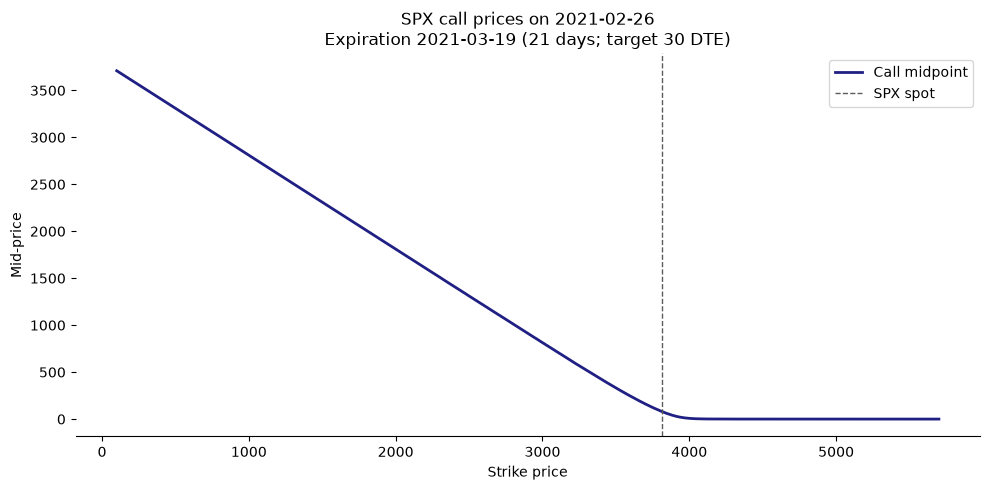

In [3]:

from implied_stock_distributions.data_access import (
    load_chain,
    load_chain_catalog,
    load_random_chain
)



def plot_call_chain(
    info: pd.Series,
    chain: pd.DataFrame,
):
    """Plot call-option mid-prices for one chain."""

    calls = (
        chain.loc[chain["put_call"].eq("call")]
        .sort_values("strike_price")
        .copy()
    )

    if calls.empty:
        raise ValueError("The selected chain contains no calls.")

    # Calculate the midpoint if it was not stored during preprocessing.
    if "mid_price" not in calls.columns:
        calls["mid_price"] = (
            calls["bid_price"] + calls["ask_price"]
        ) / 2

    data_date = pd.Timestamp(info["data_date"])
    expiration_date = pd.Timestamp(info["expiration_date"])
    actual_dte = (expiration_date - data_date).days
    spot = calls["underlying_price"].median()

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(
        calls["strike_price"],
        calls["mid_price"],
        color="#1F1F84",
        linewidth=2,
        label="Call midpoint",
    )

    ax.axvline(
        spot,
        color="#5C5C5C",
        linestyle="--",
        linewidth=1,
        label="SPX spot",
    )

    ax.set_title(
        f"SPX call prices on {data_date.date()}\n"
        f"Expiration {expiration_date.date()} "
        f"({actual_dte} days; target "
        f"{info['target_dte_days']} DTE)"
    )
    ax.set_xlabel("Strike price")
    ax.set_ylabel("Mid-price")

    for spine in ("right", "left", "top"):
        ax.spines[spine].set_visible(False)

    ax.legend()
    fig.tight_layout()

    return fig, ax


catalog = load_chain_catalog()

info, chain = load_random_chain(
    catalog,
    target_dte_days=30,
    random_state=67
)

fig, ax = plot_call_chain(info, chain)

As mentioned in the introduction, we can now regress on $C - P$ as a function of strike in order to estimate the interest rate and forward price.

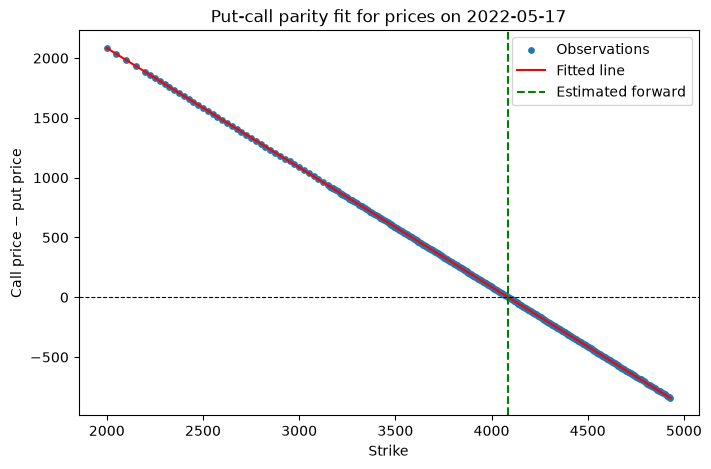

The results of the regression:


{'discount_factor': 0.9989033695451633,
 'forward': 4086.664558071975,
 'risk_free_rate': np.float64(0.012927872866141246),
 'time_to_expiry': 0.08487337440109514,
 'center_strike': 3962.5,
 'n_pairs': 360,
 'r_squared': 0.9999999664271396,
 'rmse': np.float64(0.12002036592820638)}

In [4]:
from implied_stock_distributions.forwards import estimate_forward_and_rate

info, chain = load_random_chain(
    catalog,
    target_dte_days=30,
    random_state=69
)

# for the chain we selected, use linear regression to estimate the discount factor and forward
estimates, pairs = estimate_forward_and_rate(chain)


# plot the fit
plt.figure(figsize=(8, 5))

plt.scatter(
    pairs["strike_price"],
    pairs["call_minus_put"],
    s=15,
    label="Observations",
)

plt.plot(
    pairs["strike_price"],
    pairs["fitted_call_minus_put"],
    color="red",
    label="Fitted line",
)

plt.axhline(0, color="black", linestyle="--", linewidth=0.8)

plt.axvline(
    estimates["forward"],
    color="green",
    linestyle="--",
    label="Estimated forward",
)

plt.xlabel("Strike")
plt.ylabel("Call price − put price")
plt.title(f"Put-call parity fit for prices on {info['data_date'].date()}")
plt.legend()
plt.show()


print(f"The results of the regression:")
estimates

The following cell is for diagnostic use; in the end `failures` should be empty

In [5]:
from implied_stock_distributions.data_access import iter_chains

def build_chain_diagnostics(catalog):
    records = []
    failures = []

    for i, (key, chain) in enumerate(
        iter_chains(catalog),
        start=1,
    ):
        data_date, expiration_date, target_dte = key

        if i % 100 == 0:
            print(f"Processed {i}/{len(catalog)} chains")

        try:
            estimates, pairs = estimate_forward_and_rate(
                chain,
                use_spread_weights=True,
            )

            spot = float(chain["underlying_price"].median())

            absolute_residual = pairs["parity_residual"].abs()

            # Maximum midpoint error consistent with the two spreads.
            parity_half_spread = (
                pairs["call_spread"]
                + pairs["put_spread"]
            ) / 2

            records.append({
                "data_date": data_date,
                "expiration_date": expiration_date,
                "target_dte_days": target_dte,
                **estimates,
                "spot": spot,
                "forward_over_spot": (
                    estimates["forward"] / spot
                ),
                "rmse_over_spot": (
                    estimates["rmse"] / spot
                ),
                "median_absolute_residual": float(
                    absolute_residual.median()
                ),
                "fraction_outside_spreads": float(
                    (
                        absolute_residual > parity_half_spread
                    ).mean()
                ),
            })

        except Exception as exc:
            failures.append({
                "data_date": data_date,
                "expiration_date": expiration_date,
                "target_dte_days": target_dte,
                "error": str(exc),
            })

    return (
        pd.DataFrame(records),
        pd.DataFrame(failures),
    )

# this is slow, but shouldn't be needed anymore
# diagnostics, failures = build_chain_diagnostics(catalog)

### Constructing good density functions

Although the option-price curve appears smooth at this scale, the observed quotes still contain small irregularities arising from discrete strikes, bid-ask spreads, and market noise. This matters because the Breeden-Litzenberger formula recovers the risk-neutral density from the **second derivative** of the call-price curve with respect to strike:

$$
f_Q(K) = e^{r\tau} \frac{\partial^2 C}{\partial K^2}.
$$

Taking second derivatives amplifies even small local irregularities, so applying the formula directly to observed prices can produce a very noisy density.

More importantly, an arbitrary smoothing procedure can introduce violations of the no-arbitrage conditions that a valid call-price curve must satisfy. In particular, call prices should be decreasing and convex in strike:

$$
\frac{\partial C}{\partial K}\leq 0,
\qquad
\frac{\partial^2 C}{\partial K^2}\geq 0.
$$

The second condition is especially important here: since the risk-neutral density is proportional to \(C''(K)\), any region in which the fitted call-price curve is concave would imply a **negative probability density**, and therefore an arbitrage-inconsistent result.

I compare two approaches to handling this problem.

The first is to transform the observed option prices into Black-Scholes implied volatilities and smooth the volatility smile rather than the call prices themselves. I express implied volatility as a function of log-forward-moneyness,

$$
k=\log\left(\frac{K}{F}\right),
$$

smooth the relationship in this space, and then convert the fitted implied volatilities back into option prices. This generally produces a visually smooth curve, but it does **not** guarantee that the resulting call prices satisfy all of the no-arbitrage conditions.

The second approach is based on Fengler's arbitrage-free smoothing methodology. Rather than relying on an unconstrained smooth fit, the call-price curve is estimated subject to shape restrictions such as monotonicity and convexity. These constraints are designed to prevent the fitted curve from introducing static arbitrage and, in particular, ensure that the second derivative used to recover the risk-neutral density remains non-negative.

I implement both approaches below and compare the probability densities that they produce. The implied-volatility smoothing method serves as a useful baseline, while the shape-constrained method is intended to produce a more economically consistent estimate of the risk-neutral distribution.

### An example of bad density calculation

The following cell produces a plot that shows the issue with naive numerical methods.
In this case we try just smoothing directly on the prices as a function of strike; it doesn't go well.

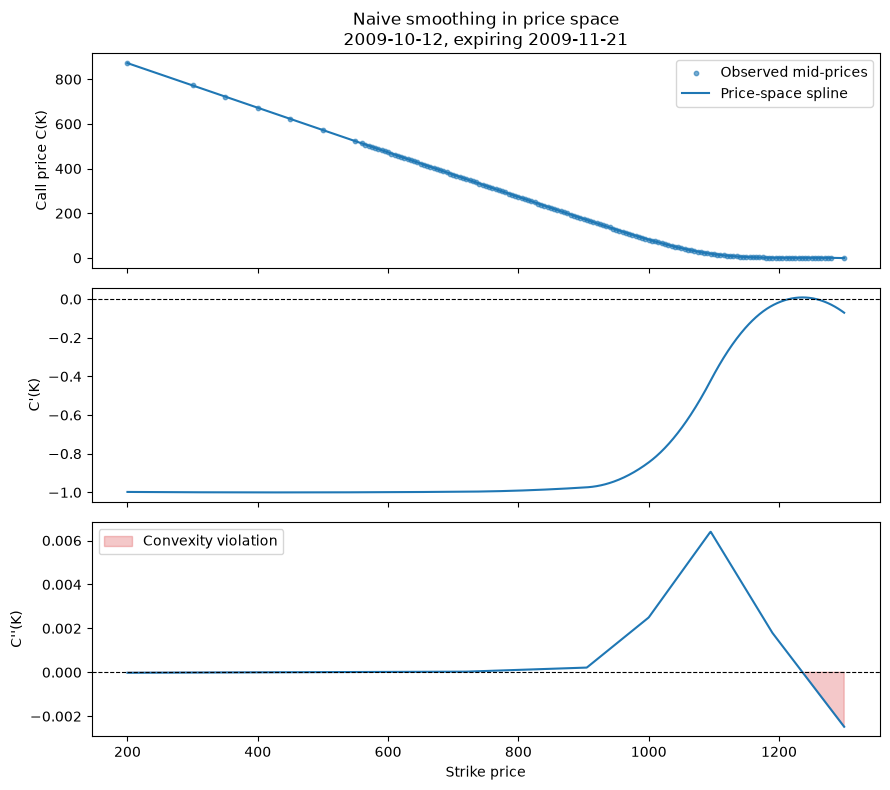

In [6]:
from scipy.interpolate import make_splrep


info, chain = load_random_chain(
    catalog,
    target_dte_days=30,
    random_state=2**12 - 1
)

# Keep only calls from the selected chain.
calls = chain.loc[chain["put_call"].eq("call")].copy()


# Optional: use only two-sided quotes for a fairer illustration
if "quote_is_two_sided" in calls.columns:
    calls = calls.loc[
        calls["quote_is_two_sided"].fillna(False)
    ]

calls = calls.loc[
    np.isfinite(calls["strike_price"])
    & np.isfinite(calls["mid_price"])
].sort_values("strike_price")

if calls["strike_price"].duplicated().any():
    raise ValueError("The chain contains duplicate call strikes.")

if len(calls) < 4:
    raise ValueError("At least four call prices are required.")

K = calls["strike_price"].to_numpy(dtype=float)
C_mid = calls["mid_price"].to_numpy(dtype=float)

# Arbitrary smoothing choice for this illustrative example
smoothing = 0.035 * len(K)

price_spline = make_splrep(
    K,
    C_mid,
    k=3,
    s=smoothing,
)

K_fine = np.linspace(K.min(), K.max(), 1000)
C_smooth = price_spline(K_fine)

# Differentiate the fitted spline itself
dC_dK = price_spline.derivative(1)(K_fine)
d2C_dK2 = price_spline.derivative(2)(K_fine)

data_date = pd.Timestamp(info["data_date"]).date()
expiration_date = pd.Timestamp(info["expiration_date"]).date()

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 8),
    sharex=True,
)

axes[0].scatter(
    K,
    C_mid,
    s=10,
    alpha=0.6,
    label="Observed mid-prices",
)
axes[0].plot(
    K_fine,
    C_smooth,
    linewidth=1.5,
    label="Price-space spline",
)
axes[0].set_ylabel(r"Call price C(K)")
axes[0].legend()
axes[0].set_title(
    "Naive smoothing in price space\n"
    f"{data_date}, expiring {expiration_date}"
)

axes[1].plot(K_fine, dC_dK, linewidth=1.5)
axes[1].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=0.8,
)
axes[1].set_ylabel(r"C'(K)")

axes[2].plot(K_fine, d2C_dK2, linewidth=1.5)
axes[2].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=0.8,
)

# Highlight regions that violate call-price convexity
axes[2].fill_between(
    K_fine,
    d2C_dK2,
    0,
    where=d2C_dK2 < 0,
    color="tab:red",
    alpha=0.25,
    label="Convexity violation",
)

axes[2].set_ylabel(r"C''(K)")
axes[2].set_xlabel("Strike price")
axes[2].legend()

fig.tight_layout()
plt.show()

In the following cell, we define functions that convert the price data to implied volatility, perform a smoothed interpolation, convert back to price, and then compute the second derivative.
This tends to give nice smooth-looking results, but can easily violate no-arbitrage conditions.
In the final plot, this is compared with the method based on Fengler's approach.
It may not look as nice, but it will be the better approach overall.

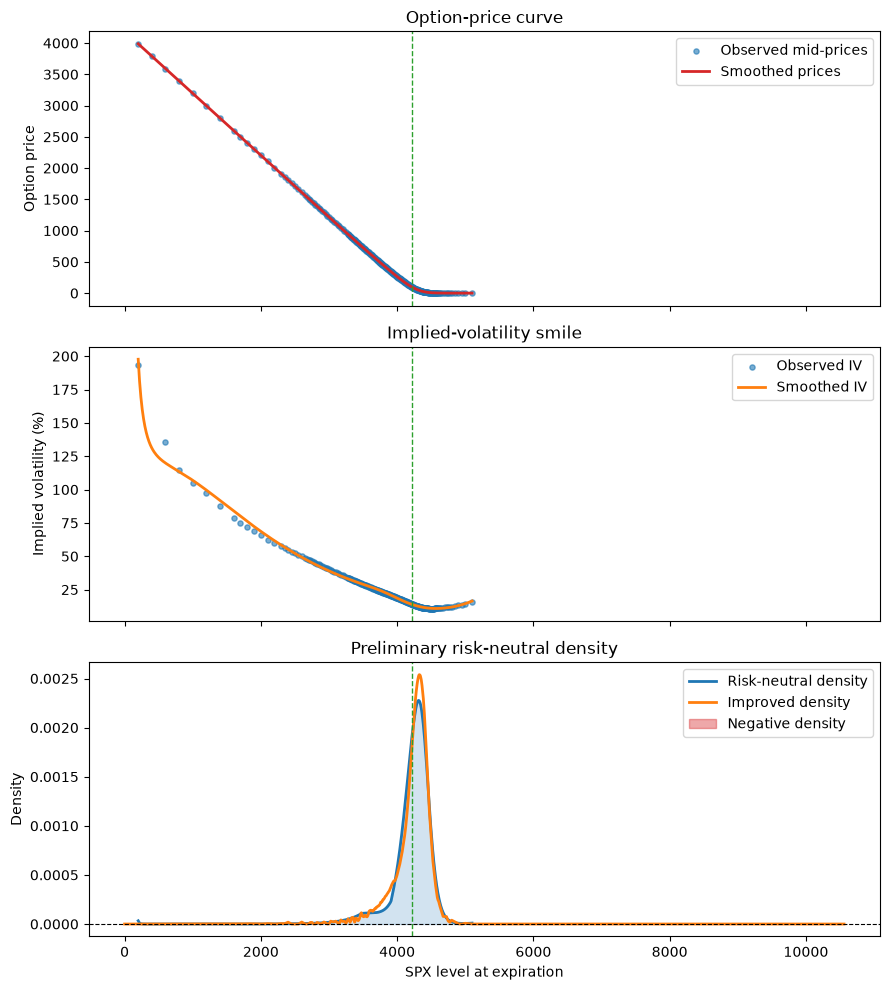

In [7]:

from implied_stock_distributions.smoothing import create_density_from_chain, compute_implied_vols


info, chain = load_random_chain(
    catalog,
    target_dte_days=60,
)

# this is the first attempt to construct the density that isn't that good, although it probably looks nicer on the graph
results = (
    create_density_from_chain(
        chain=chain,
        option_type="call",
        smoothing_factor=.15
    )
)
strike_grid, smooth_prices, density, iv_curve = results.values() # bad practice but ok


# this is the better way to do it
from implied_stock_distributions.fitting import fit_shape_constrained_call_spline, construct_risk_neutral_distribution_from_spline

# fit a spline to the data
fit = fit_shape_constrained_call_spline(
    chain,
    roughness_penalty=1,
    upper_support_multiple=2.5,
)

# turn the spline into an actual distribution
distribution = construct_risk_neutral_distribution_from_spline(
    fit
)


option_type = "call"

forward = estimates["forward"]
risk_free_rate = estimates["risk_free_rate"]
time_to_expiry = float(
    chain["time_to_expiry_years"].iloc[0]
)

quotes = chain.loc[
    chain["put_call"].eq(option_type)
].copy()

if "quote_is_two_sided" in quotes.columns:
    quotes = quotes.loc[
        quotes["quote_is_two_sided"].fillna(False)
    ]


# Calculate the unsmoothed IV observations for comparison.

# first we have to get the forward and risk_free_rate
estimates, _ = estimate_forward_and_rate(chain)
forward = estimates["forward"]
risk_free_rate = estimates["risk_free_rate"]

observed_strikes, observed_iv = compute_implied_vols(
    strikes=quotes["strike_price"],
    prices=quotes["mid_price"],
    forward=forward,
    time_to_expiry=time_to_expiry,
    option_type=option_type,
    risk_free_rate=risk_free_rate,
)

fitted_iv = iv_curve(strike_grid)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(9, 10),
    sharex=True,
)

# Observed and reconstructed prices
axes[0].scatter(
    quotes["strike_price"],
    quotes["mid_price"],
    s=14,
    alpha=0.6,
    label="Observed mid-prices",
)
axes[0].plot(
    strike_grid,
    smooth_prices,
    color="tab:red",
    linewidth=2,
    label="Smoothed prices",
)
axes[0].set_ylabel("Option price")
axes[0].set_title("Option-price curve")
axes[0].legend()

# Observed and fitted implied volatility
axes[1].scatter(
    observed_strikes,
    100 * observed_iv,
    s=14,
    alpha=0.6,
    label="Observed IV",
)
axes[1].plot(
    strike_grid,
    100 * fitted_iv,
    color="tab:orange",
    linewidth=2,
    label="Smoothed IV",
)
axes[1].set_ylabel("Implied volatility (%)")
axes[1].set_title("Implied-volatility smile")
axes[1].legend()

# Preliminary risk-neutral density
axes[2].plot(
    strike_grid,
    density,
    color="tab:blue",
    linewidth=2,
    label="Risk-neutral density",
)
axes[2].plot(
    distribution["strike_grid"],
    distribution["density"],
    color="tab:orange",
    # opacity=0.4,
    linewidth=2,
    label="Improved density"
)
axes[2].fill_between(
    strike_grid,
    density,
    0,
    where=density >= 0,
    color="tab:blue",
    alpha=0.2,
)
axes[2].fill_between(
    strike_grid,
    density,
    0,
    where=density < 0,
    color="tab:red",
    alpha=0.4,
    label="Negative density",
)
axes[2].axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=0.8,
)
axes[2].set_xlabel("SPX level at expiration")
axes[2].set_ylabel("Density")
axes[2].set_title("Preliminary risk-neutral density")
axes[2].legend()

# Show the estimated forward on every graph.
for ax in axes:
    ax.axvline(
        forward,
        color="tab:green",
        linestyle="--",
        linewidth=1,
    )

fig.tight_layout()
plt.show()


# Part 2: Evaluating the probability distributions

Having constructed risk-neutral probability distributions from historical option chains, the next step is to compare each distribution with the SPX level that was actually realized at expiration.

Because each model produces an entire probability distribution rather than a single point forecast, I evaluate performance using the **continuous ranked probability score (CRPS)**. For a forecast distribution $D$ and realized outcome $y$, the CRPS is defined as

It is defined by
$$ C(D, y) = \int_{\mathbb R} (F_D(x) - \mathbf 1_{x \geq y})^2 \, dx, $$
where
- $F_D$ is the cumulative distribution function of the forecasted distribution $D$,
- $\mathbf 1_{x \geq y}$ is the indicator function, which is 1 if $x \geq y$ and 0 otherwise, and
- $y \in \mathbb R$ is the observation.


Conceptually, the CRPS measures the distance between the forecast CDF and the step-function CDF corresponding to the realized outcome. I evaluate this integral numerically for each forecast distribution.

A **lower CRPS indicates a better probabilistic forecast**. The minimum possible value is 0, which would occur only if the forecast placed all probability mass exactly on the realized outcome.

Unlike an error metric based on a single predicted value, the CRPS evaluates the **entire distribution**. It rewards forecasts that place substantial probability near the realized outcome, while penalizing distributions that are either poorly centered or unnecessarily diffuse. In this sense, it captures both the accuracy and the sharpness of the forecast.

The CRPS has the same units as the quantity being forecast. In this analysis, the score is therefore measured in normalized SPX index points.

We'll use the SET settlement data for our realized settlement scores.

Now we implement the CRPS function described above, and a function that will calculate the CRPS given a dataframe of option data.

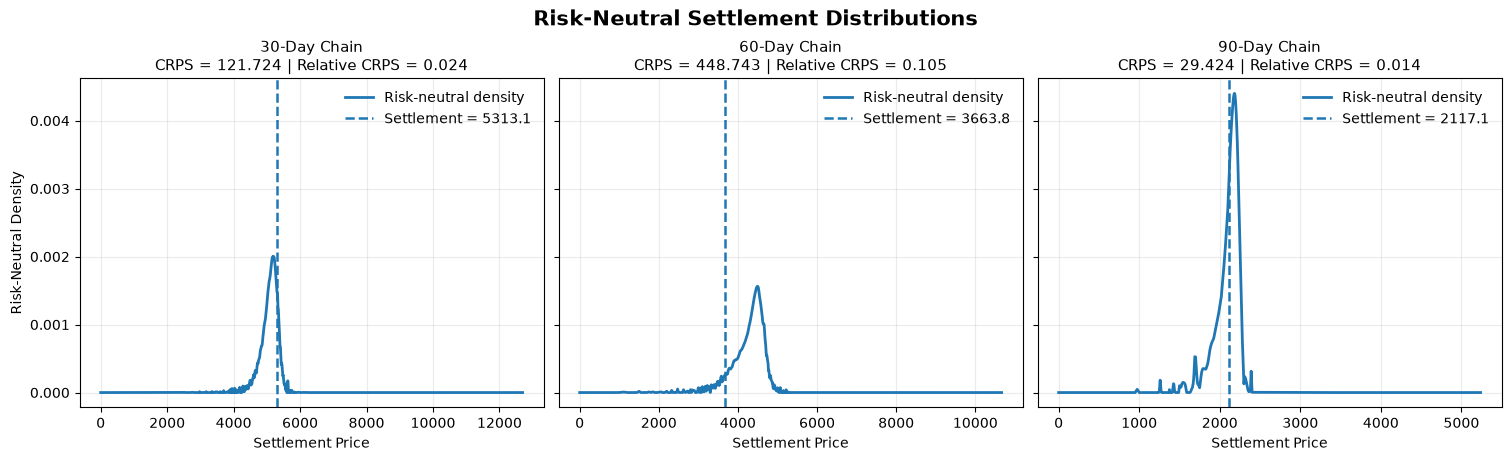

In [8]:
settlement_values = pd.read_parquet("../data/processed/cboe_spx_set_values.parquet")

from implied_stock_distributions.evaluation import evaluate_risk_neutral_prediction_from_chain, evaluate_risk_neutral_prediction_from_chain_iv_smoothing

days_list = [30, 60, 90]

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 4.5),
    sharey=True,
    constrained_layout=True,
)

for ax, days in zip(axes, days_list):

    info, chain = load_random_chain(
        catalog,
        days,
        random_state=2,
    )

    # get the observed settlement price
    expiry = pd.Timestamp(chain["expiration_date"].iloc[0])

    set_val = settlement_values.loc[
        (settlement_values["expiration_year"] == expiry.year)
        & (settlement_values["expiration_month"] == expiry.month),
        "set_value",
    ]

    if len(set_val) != 1:
        raise ValueError(
            f"Expected one settlement value for "
            f"{expiry.year}-{expiry.month:02d}, found {len(set_val)}."
        )

    set_val = float(set_val.iloc[0])

    results = evaluate_risk_neutral_prediction_from_chain(
        chain,
        set_val,
        option_type="call",
    )

    # Plot density
    ax.plot(
        results["strike_grid"],
        results["density"],
        linewidth=2,
        label="Risk-neutral density",
    )

    # Observed settlement
    ax.axvline(
        set_val,
        linestyle="--",
        linewidth=1.8,
        label=f"Settlement = {set_val:.1f}",
    )

    # Formatting
    ax.set_title(
        f"{days}-Day Chain\n"
        f"CRPS = {results['crps']:.3f} | "
        f"Relative CRPS = {results['relative_crps']:.3f}",
        fontsize=11,
    )

    ax.set_xlabel("Settlement Price")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

axes[0].set_ylabel("Risk-Neutral Density")

fig.suptitle(
    "Risk-Neutral Settlement Distributions",
    fontsize=15,
    fontweight="bold",
)

plt.show()

We can fit and cache all the densities once, and then for things like testing CRPS, we don't have to repeat this expensive and time-consuming calculation later.

In [ ]:
import pickle

rn_predictions_constrained_smoothing = []
rn_predictions_iv_smoothing = []

for i, (key, chain) in enumerate(iter_chains(catalog), start=1):
    data_date, expiration_date, target_dte = key

    if i % 100 == 0:
        print(f"Constructed {i}/{len(catalog)} risk-neutral densities")
        # break after 100 first to test
        # break

    try:
        expiry = pd.Timestamp(expiration_date)

        # Realized settlement value
        set_val = settlement_values.loc[
            (settlement_values["expiration_year"] == expiry.year)
            & (settlement_values["expiration_month"] == expiry.month),
            "set_value",
        ]

        if len(set_val) != 1:
            print(f"Skipping {key}: couldn't identify settlement value")
            continue

        realized_value = float(set_val.iloc[0])

        # Fit option-price curve
        fit = fit_shape_constrained_call_spline(
            chain,
            roughness_penalty=1,
            upper_support_multiple=2.5,
        )

        # Construct risk-neutral density
        distribution = construct_risk_neutral_distribution_from_spline(fit)

        s = np.asarray(distribution["strike_grid"], dtype=float)
        fQ = np.asarray(distribution["density"], dtype=float)

        # Clean
        mask = np.isfinite(s) & np.isfinite(fQ) & (s > 0)
        s = s[mask]
        fQ = np.clip(fQ[mask], 0, None)

        # Normalize
        mass = np.trapezoid(fQ, s)

        if not np.isfinite(mass) or mass <= 0:
            print(f"Skipping {key}: invalid density")
            continue

        fQ = fQ / mass

        rn_predictions_constrained_smoothing.append({
            "data_date": pd.Timestamp(data_date),
            "expiration_date": expiry,
            "target_dte": int(target_dte),
            "realized_value": realized_value,
            "strike_grid": s,
            "fQ": fQ,
        })

        # now do it all for the iv-smoothing method
        estimates, _ = estimate_forward_and_rate(
            chain,
            use_spread_weights=False,
        )

        results = create_density_from_chain(
            chain
        )

        rn_predictions_iv_smoothing.append({
            "data_date": pd.Timestamp(data_date),
            "expiration_date": expiry,
            "target_dte": int(target_dte),
            "realized_value": realized_value,
            "strike_grid": results["strike_grid"],
            "fQ": results["density"]
        })

    except Exception as exc:
        print(f"Skipping {key}: {exc}")


print(f"\nSuccessfully constructed {len(rn_predictions_constrained_smoothing)} distributions via constrained smoothing\
      and {len(rn_predictions_iv_smoothing)} via implied volatility smoothing.")


# ------------------------------------------------------------
# Save to disk
# ------------------------------------------------------------

output_dir = Path("../data/processed/cached_densities")
output_dir.mkdir(exist_ok=True)

output_file_1 = output_dir / "rn_predictions_constrained_smoothing.pkl"
output_file_2 = output_dir / "rn_predictions_iv_smoothing.pkl"

with open(output_file_1, "wb") as f:
    pickle.dump(rn_predictions_constrained_smoothing, f)
print(f"Saved to: {output_file_1.resolve()}")


with open(output_file_2, "wb") as f:
    pickle.dump(rn_predictions_iv_smoothing, f)
print(f"Saved to: {output_file_2.resolve()}")


Constructed 100/6919 risk-neutral densities


Before we do the calculation, we can demonstrated a few graphs of pdfs together with the actual value of the underlying at expiration of the options from which we derive the pdf, as well as the CRPS score of the prediction and outcome.

In [ ]:
from implied_stock_distributions.evaluation import crps_from_density_grid


# calculate the average CRPS score across all chains
# hopefully this method will never be used again, after I cache the densities as above
def compute_average_scores():
    count = 0
    total_crps_good_method = 0
    total_relative_crps_good_method = 0

    total_crps_bad_method = 0
    total_relative_crps_bad_method = 0

    for info, chain in iter_chains(catalog):
        count += 1

        # get the observed settlement price
        expiry = pd.Timestamp(chain["expiration_date"].iloc[0])

        set_val = settlement_values.loc[
            (settlement_values["expiration_year"] == expiry.year)
            & (settlement_values["expiration_month"] == expiry.month),
            "set_value",
        ]

        if len(set_val) != 1:
            raise ValueError(
                f"Expected one settlement value for "
                f"{expiry.year}-{expiry.month:02d}, found {len(set_val)}."
            )

        set_val = float(set_val.iloc[0])


        results_good_method = evaluate_risk_neutral_prediction_from_chain(
            chain,
            set_val,
            option_type="call",
        )

        results_bad_method = evaluate_risk_neutral_prediction_from_chain_iv_smoothing(
            chain,
            set_val,
            option_type="call"
        )

        total_crps_bad_method += results_bad_method["crps"]
        total_relative_crps_bad_method += results_bad_method["relative_crps"]

        total_crps_good_method += results_good_method["crps"]
        total_relative_crps_good_method += results_good_method["relative_crps"]
        
    print(f"Average relative CRPS for good method: {total_relative_crps_good_method / count}.")
    print(f"Average relative CRPS for bad method: {total_relative_crps_bad_method / count}.")


def evaluate_cached_density(obs):
    strike_grid = np.asarray(
        obs["strike_grid"],
        dtype=float,
    )

    density = np.asarray(
        obs["fQ"],
        dtype=float,
    )

    realized_value = float(
        obs["realized_value"]
    )

    crps = crps_from_density_grid(
        strike_grid=strike_grid,
        density=density,
        realized_value=realized_value,
    )

    relative_crps = (
        crps / realized_value
    )

    return {
        "crps": crps,
        "relative_crps": relative_crps,
    }


def prediction_key(obs):
    return (
        pd.Timestamp(obs["data_date"]),
        pd.Timestamp(obs["expiration_date"]),
        int(obs["target_dte"]),
    )


def compute_average_scores(
    rn_predictions_constrained_smoothing,
    rn_predictions_iv_smoothing,
):
    # Build dictionaries so observations are matched correctly
    constrained = {
        prediction_key(obs): obs
        for obs in rn_predictions_constrained_smoothing
    }

    iv = {
        prediction_key(obs): obs
        for obs in rn_predictions_iv_smoothing
    }

    # Only compare observations for which BOTH methods succeeded
    common_keys = sorted(set(constrained) & set(iv))

    rows = []

    for key in common_keys:
        good_obs = constrained[key]
        bad_obs = iv[key]

        good_results = evaluate_cached_density(good_obs)
        bad_results = evaluate_cached_density(bad_obs)

        rows.append({
            "data_date": key[0],
            "expiration_date": key[1],
            "target_dte": key[2],

            "crps_constrained": good_results["crps"],
            "relative_crps_constrained":
                good_results["relative_crps"],

            "crps_iv": bad_results["crps"],
            "relative_crps_iv":
                bad_results["relative_crps"],
        })

    scores = pd.DataFrame(rows)

    print()
    print(
        "Average relative CRPS for constrained smoothing: "
        f"{scores['relative_crps_constrained'].mean():.6f}"
    )

    print(
        "Average relative CRPS for IV smoothing: "
        f"{scores['relative_crps_iv'].mean():.6f}"
    )

    return scores

cache_dir = Path("../data/processed/cached_densities")

with open(cache_dir / "rn_predictions_constrained_smoothing.pkl", "rb") as f:
    rn_predictions_constrained_smoothing = pickle.load(f)

with open(cache_dir / "rn_predictions_iv_smoothing.pkl", "rb") as f:
    rn_predictions_iv_smoothing = pickle.load(f)


scores = compute_average_scores(
    rn_predictions_constrained_smoothing,
    rn_predictions_iv_smoothing,
)




In [ ]:
print(0.034475 / 0.040064)

We see that Fengler's constrained smoothing has better predictive power than the IV-smoothing method.
This is mostly a curiosity, as predictive power isn't necessarily a desired feature of a risk-neutral probability, and there are better reasons to prefer the constrained smoothing method anyway.

# Part 3: converting the risk-neutral density to a real-world density

See Section 16.9 of the book Asset Price Dynamics, Volatility, and Prediction by Stephen Taylor.

As discussed before, the density that we are extracting from the option prices is not just purely the market's prediction of where the stock is likely to move.
So far I have obtained a density $f_Q$ for the risk-neutral probability measure $Q$, and I would like to convert this to a density $f_P$ for the real-world probability measure $P$.
This may not be possible in general, but there should be some things we can say.

Recall our previous calculation that
$$
\begin{aligned}
C(K, T) &= e^{-rT} \mathbb E_Q(\max\{S_T - K, 0\}) \\
&= e^{-rT} \int_0^\infty \max\{x - K, 0\} f_Q(x) \, d x
\end{aligned}
$$
We can continue this:
$$
\begin{aligned}
\qquad \qquad \qquad \quad &= e^{-rT} \int_0^\infty \max\{x - K, 0\} \frac{f_Q(x)}{f_P(x)} f_P(x) \, dx \\
&= \mathbb E_P[ \max\{S_T - K, 0\} \cdot m(S_T) ],
\end{aligned}
$$
where $m(S_T)$ is a random variable called the *stochastic discount factor*, and is defined by the equation above, so that
$$
m(S_T) = e^{-r T} \frac{f_Q(S_T)}{f_P(S_T)}.
$$
So this discount factor encodes the difference (technically the ratio) between the risk-neutral distribution and the real-world distribution.
In order to actually obtain a real-world distribution, we need to make some modeling assumptions.

Under additional assumptions, the stochastic discount factor can be related to the marginal utility of a representative investor. If terminal consumption or wealth is taken to be proportional to the terminal value of the underlying, then a power-utility specification implies a pricing kernel of the form
$$ m(S_T) \propto S_T^{-\gamma}. $$

Under some assumptions, one can relate the stochastic discount factor to the utility function of a representative investor.
Suppose the amount that an investor cares about future wealth $W_T$ is described by a utility function
$$ u(W_T). $$
Then the value of an extra dollar is measured by *marginal utility* $u'(W_T)$.
In a bad state, where wealth is low, this derivative is large, and in a good state this derivative is small.
This marginal utility gives the same information as the stochastic discount factor: it says how valuable one dollar delivered in different states is.
So we can reasonably suppose that
$$ m_T \propto u'(W_T). $$
We can also suppose that future wealth is proportional to the stock/index level: $W_T \propto S_T$.
This is more of a convenience than a philosophical restriction, but it allows us to write
$$ m(S_T) \propto u'(S_T). $$
One common model of utility is [power utility](https://en.wikipedia.org/wiki/Isoelastic_utility), also known as isoelastic utility:
$$ u(W) = \frac{W^{1 - \gamma}}{1 - \gamma}. $$
Then $u'(W) = W^{-\gamma}$, so $m(S_T) \propto S_T^{-\gamma}$.
But this means that
$$ \frac{f_Q(S_T)}{f_P(S_T)} \propto S_T^{-\gamma},$$
or
$$ f_P(s) \propto s^\gamma f_Q(s). $$
We know that $f_P$ must integrate to $1$, i.e.
$$ f_P(s) = \frac{s^\gamma f_Q(s)}{\int_0^\infty y^\gamma f_Q(y) \, dy}. $$
Since (with $\gamma > 0$), $s^\gamma$ is small for low stock prices and high for large stock prices, this tells us that going from $Q$ to $P$ downweights the probability of low-price states and upweights the probability of high-price states.
This is because we are undoing the effect that the market overvalues money in low-price states (relative to the probability of occurrence).

$$
u(x) =
\begin{cases}
\displaystyle \frac{x^{1-\gamma}}{1 - \gamma}, &\gamma \neq 1 \\
\log(x), &\gamma = 1.
\end{cases}
$$
This gives $m(x) \propto x^{-\gamma}$, and so
$$
f_P(x) = \frac{\displaystyle x^\gamma f_Q(x)}{\displaystyle \int_0^\infty y^\gamma f_Q(y) \, dy}.
$$
Below I implement this formula.

In [ ]:
from scipy.optimize import minimize_scalar
from implied_stock_distributions.evaluation import physical_density_from_rn_grid, average_relative_crps_for_gamma



result = minimize_scalar(
    average_relative_crps_for_gamma,
    args=(rn_predictions_constrained_smoothing,),
    bounds=(0, 5),
    method="bounded",
)


gamma_hat = result.x

print(f"Estimated gamma: {gamma_hat:.6f}")
print(f"Average CRPS: {result.fun:.6f}")
print(f"Optimization successful: {result.success}")


gamma_grid = np.linspace(0, 5, 61)

average_crps_values = np.array([
    average_relative_crps_for_gamma(
        gamma,
        rn_predictions_constrained_smoothing,
    )
    for gamma in gamma_grid
])


plt.figure(figsize=(8, 5))

plt.plot(
    gamma_grid,
    average_crps_values,
    marker="o",
    markersize=3,
)

plt.axvline(
    gamma_hat,
    linestyle="--",
    label=fr"Estimated $\gamma$ = {gamma_hat:.2f}",
)

plt.xlabel(r"$\gamma$")
plt.ylabel("Average CRPS")
plt.title(r"Average CRPS as a function of $\gamma$")
plt.legend()
plt.show()


In [ ]:
plt.figure(figsize=(9, 6))

for dte in [30, 60, 90]:

    subset = [
        obs
        for obs in rn_predictions_constrained_smoothing
        if obs["target_dte"] == dte
    ]

    crps_values = [
        average_crps_for_gamma(gamma, subset)
        for gamma in gamma_grid
    ]

    plt.plot(
        gamma_grid,
        crps_values,
        linewidth=2,
        label=f"{dte}-day horizon",
    )

plt.xlabel(r"$\gamma$")
plt.ylabel("Average CRPS")
plt.title(r"Average CRPS vs. $\gamma$ by forecast horizon")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# Conclusion

This project examined how probability distributions for future SPX levels can be recovered from observed option prices and how those distributions relate to realized market outcomes.

The first challenge was numerical. The Breeden-Litzenberger relation makes the risk-neutral density proportional to the second derivative of the call-price curve with respect to strike, so even small irregularities in observed prices can produce unstable or economically invalid densities. I therefore explored different approaches to smoothing the option data and ultimately used a shape-constrained call-price fit designed to preserve the monotonicity and convexity conditions implied by no-arbitrage. Across the 6,919 matched option chains in the sample, this method produced a lower average relative CRPS than the alternative implied-volatility smoothing approach: approximately $0.0345$, compared with $0.0401$.

The second part of the project evaluated the recovered distributions against realized SPX settlement values. CRPS is useful here because it evaluates the complete forecast distribution rather than reducing it to a single predicted value. At the same time, the exercise illustrates an important limitation of interpreting risk-neutral densities as forecasts. These densities are constructed from market prices under the risk-neutral measure $Q$, so they incorporate investors' pricing of risk as well as expectations about future outcomes.

The final part explored one possible way to account for this distinction. Under a representative-investor model with CRRA utility, the physical density can be written as

$$ f_P(s) \propto s^\gamma f_Q(s). $$

I estimated the parameter $\gamma$ by minimizing average CRPS over the available historical observations, obtaining an estimate of approximately $1.32$, although with little difference for $\gamma$ in a range of about $(0, 3.25)$. Within this sample, the transformed distributions achieved a lower CRPS than the untransformed risk-neutral distributions. This is encouraging evidence that accounting for the pricing kernel can move the option-implied distribution in a direction that better matches realized outcomes. However, because $\gamma$ was selected using the same observations on which performance was measured, this result should be interpreted as an in-sample fit rather than evidence of improved out-of-sample forecasting performance.

There are several natural ways to extend the project. The density-estimation procedure could be improved through more sophisticated models of the volatility smile and better treatment of the tails, which are especially important when estimating probabilities of extreme outcomes. The physical-density transformation could also be estimated on a training sample and evaluated on held-out data, allowing a genuine test of whether the pricing kernel is stable enough to improve future forecasts. More generally, rather than imposing a particular CRRA form, one could attempt to estimate a flexible pricing kernel directly from historical pairs of option-implied distributions and realized outcomes. It would be especially interesting to restrict to training data for estimating the pricing kernel, and then check if forecasting performance is improved on out-of-sample data.

The central lesson of the project is that option prices provide a rich source of information about the market's valuation of future states, but extracting and interpreting that information requires both numerical care and economic assumptions. Risk-neutral densities are observable from prices to a much greater extent than real-world probabilities are; the more difficult problem is understanding what transformation, if any, allows the former to become useful forecasts of the latter.

# References and further reading

Here I have collected some sources of information for this project, as well as some interesting resources related to the topics discussed.


### **Smoothing**

- [Arbitrage-Free Smoothing of the Implied Volatility Surface - Matthias R. Fengler](https://edoc.hu-berlin.de/server/api/core/bitstreams/4af0fb58-fda0-4e91-8fb2-fa451714a275/content)

### **Market-implied probabilities**

- [Are market implied probabilities useful?](https://blog.thinknewfound.com/2017/11/market-implied-probabilities-useful/) - A blog post.

- [A blog post titled "Options Implied Distributions are NOT Real-World Distributions"](https://freeportlogbook.substack.com/p/options-implied-distributions-are) - A blog post.

### **Estimating real-world probabilities from option-implied risk-neutral probabilities**

- [What is Risk-Neutral Probability Analysis?](https://www.optionsanalysissuite.com/documentation/probability)

- [Understanding the Connection between Real-World and Risk-Neutral Scenario Generators.](https://www.soa.org/4ab88e/globalassets/assets/files/resources/research-report/2022/understanding-the-connection.pdf) - an SOA Research Institute article.

- [Steve Ross: The Recovery Theorem.](https://onlinelibrary.wiley.com/doi/abs/10.1111/jofi.12092) - A theorem about recovering the real-world probability distribution from the market-implied one.

- [Does the Ross recovery theorem work empirically?](https://www.sciencedirect.com/science/article/abs/pii/S0304405X20300763) - An article that gives some evidence that the Ross recovery theorem may break down in the real world.

- [Estimating the real-world density from the option-implied risk-neutral density.](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2093397) - A paper.

- [Quant stackexchange.](https://quant.stackexchange.com/questions/50700/what-is-the-connection-between-the-risk-neutral-implied-density-and-the-real-wor/50701#50701) - A post about estimating the implied real-world density from option prices.


- [Bakshi, Kapadia, and Madan (2003) risk-neutral moment estimators: A Gram–Charlier density approach](https://link.springer.com/article/10.1007/s11147-022-09187-x)

### **Other topics**

- [Wikipedia article on scoring rules](https://en.wikipedia.org/wiki/Scoring_rule).
These are rules that are used to assign a score to a predicted probability distribution and an observed value; exactly what we are doing to compare the risk-neutral distributions to real market movements.


- [Stephen Taylor: Asset Prices Dynamics, Volatility, and Prediction.](https://ia801604.us.archive.org/20/items/quant_books/Asset%20Price%20Dynamics%2C%20Volatility%20_%20Prediction%20-%20S.%20J.%20Taylor.pdf) - A really good book about a lot of different topics related to this project.
In particular see chapter 16: Density Prediction for Asset Prices, and section 16.9: From Risk-Neutral to Real-World Densities